# Decomposing colony dispersion with partial lineage information

This experiment asks:

> How much of the observed change in colony dispersion is attributable to spatial transport, and how much is attributable to the creation of new cells by division?

The [Tracking One-in-a-Million (TOIAM) dataset](https://zenodo.org/records/7260137) contains five one-minute time-lapse sequences of growing *Corynebacterium glutamicum* in Cell Tracking Challenge (CTC) format. We use the segmented configurations as untracked snapshots and reveal only a fixed fraction of complete division events. The withheld lineage is used for an oracle comparison.

Each segmented cell is replaced by one fixed-width Gaussian centered at its centroid:
$$
\bar\rho_k(x)=\sum_{a\in C_k}G_\sigma(x-c_{a,k}),
\qquad
\int_\Omega G_\sigma(x-c_{a,k})\,dx=1.
$$
Thus $\bar\rho_k$ is a spatial **cell-count measure**, not biomass. Elongation, rotation, and mask deformation do not become apparent transport.

We compare three paths, all on the same grid and time window:

1. an unconstrained WFR geodesic whose transport/source penalty scale $\delta$ is calibrated against the observed intermediate densities;
2. ACUOT with moment constraints and a source interval estimated from partial lineage;
3. ACUOT with the same moment constraints and the exact full-lineage source observable, used as an oracle.

The $\delta$ calibration uses the same window as evaluation and is therefore an in-sample calibration score, not an out-of-sample performance claim.

## Observable, decomposition, and affine information

For a density $\rho(t)$, define
$$
N(t)=\int_\Omega d\rho_t,\qquad
\mu(t)=\frac{1}{N(t)}\int_\Omega x\,d\rho_t,
$$
and the dispersion
$$
O(t)=\frac{1}{N(t)}\int_\Omega |x-\mu(t)|^2\,d\rho_t.
$$
With $q(t,x)=|x-\mu(t)|^2$, the centroid identity makes the integral of $\partial_t q$ vanish. The continuity equation then gives
$$
\frac{dO}{dt}=T(t)+S(t),
$$
where
$$
T(t)=\frac{1}{N(t)}\int_\Omega 2(x-\mu(t))\cdot d\omega_t,
\qquad
S(t)=\frac{1}{N(t)}\int_\Omega \bigl(q(t,x)-O(t)\bigr)\,d\zeta_t.
$$

At every observed node we retain the cell count, two first moments, and raw second moment. ACUOT constraints act on centered densities, so their equality targets are adjacent averages of the observed **raw moments**. Since the centered density is the average of two neighboring staggered densities and the first endpoint is fixed, these equalities recursively encode every observed node moment.

For interval $k$, partial lineage supplies a finite-population interval
$$
\ell_k\le
\int_\Omega
\frac{q_k(x)-O_k}{N_k}\,d\zeta_k(x)
\le u_k.
$$
The experiment assumes binary division, no death or field-of-view entry/exit in the selected window, and uniform sampling of complete parent-division events.

In [17]:
from collections import defaultdict
from pathlib import Path
import os
import re
import sys

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from scipy.stats import t as student_t


def env_flag(name, default=False):
    value = os.environ.get(name)
    if value is None:
        return bool(default)
    return value.strip().lower() in {"1", "true", "yes", "on"}


def env_path(name):
    value = os.environ.get(name)
    return Path(value).expanduser().resolve() if value else None


def print_table(rows, columns=None, digits=4):
    if not rows:
        print("(no rows)")
        return
    columns = list(columns or rows[0].keys())

    def format_value(value):
        if isinstance(value, (float, np.floating)):
            return f"{float(value):.{digits}g}"
        return str(value)

    formatted = [
        [format_value(row.get(column, "")) for column in columns]
        for row in rows
    ]
    widths = [
        max(len(column), *(len(row[j]) for row in formatted))
        for j, column in enumerate(columns)
    ]
    print(" | ".join(column.ljust(width) for column, width in zip(columns, widths)))
    print("-+-".join("-" * width for width in widths))
    for row in formatted:
        print(" | ".join(value.ljust(width) for value, width in zip(row, widths)))


# Import the local package when launched from either the repository root or paper/.
_cwd = Path.cwd().resolve()
REPO_ROOT = next(
    (
        candidate
        for candidate in (_cwd, _cwd.parent)
        if (candidate / "src" / "acuot").is_dir()
    ),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError("Run this notebook from the ACUOT repository root or paper/ directory.")
sys.path.insert(0, str(REPO_ROOT / "src"))

from acuot import computeGeodesic


# Data and window. TOIAM_ROOT must contain directories such as 00_GT/TRA.
TOIAM_ROOT = env_path("TOIAM_ROOT") or (REPO_ROOT / "paper" / "input" / "toiam")
SEGMENTATION_DIR_OVERRIDE = env_path("TOIAM_SEG_DIR")
TRACKING_DIR_OVERRIDE = env_path("TOIAM_TRACK_DIR")
SEQUENCE = os.environ.get("TOIAM_SEQUENCE", "00")

FRAME_START = int(os.environ.get("TOIAM_FRAME_START", "300"))
FRAME_STOP = int(os.environ.get("TOIAM_FRAME_STOP", "440"))
FRAME_STRIDE = int(os.environ.get("TOIAM_FRAME_STRIDE", "20"))
FRAME_DT_MINUTES = float(os.environ.get("TOIAM_FRAME_DT_MINUTES", "1.0"))
PIXEL_SIZE_UM = float(os.environ.get("TOIAM_PIXEL_SIZE_UM", "0.072"))

# Spatial representation and partial-lineage experiment.
GRID_LONG_SIDE = int(os.environ.get("TOIAM_GRID_LONG_SIDE", "32"))
SIGMA_GRID_CELLS = float(os.environ.get("TOIAM_SIGMA_GRID_CELLS", "1.0"))
REVEAL_FRACTION = float(os.environ.get("TOIAM_REVEAL_FRACTION", "0.5"))
SEED = int(os.environ.get("TOIAM_SEED", "58"))

# A short fixed grid keeps delta calibration transparent and reproducible.
DELTA_CANDIDATES = np.array(
    [
        float(value)
        for value in os.environ.get(
            "TOIAM_DELTA_GRID", "0.05,0.1,0.4,0.8,1,2,5"
        ).split(",")
    ],
    dtype=float,
)
PPXA_ITERATIONS = int(os.environ.get("TOIAM_PPXA_ITERATIONS", "10000"))
PPXA_ALPHA = float(os.environ.get("TOIAM_PPXA_ALPHA", "1.8"))
VERBOSE_SOLVER = env_flag("TOIAM_VERBOSE_SOLVER", True)

if FRAME_STOP <= FRAME_START or FRAME_STRIDE <= 0:
    raise ValueError("Require FRAME_STOP > FRAME_START and FRAME_STRIDE > 0.")
if (FRAME_STOP - FRAME_START) % FRAME_STRIDE:
    raise ValueError("FRAME_STOP - FRAME_START must be divisible by FRAME_STRIDE.")
if not (0 < REVEAL_FRACTION <= 1):
    raise ValueError("REVEAL_FRACTION must lie in (0, 1].")
if GRID_LONG_SIDE < 8 or SIGMA_GRID_CELLS <= 0:
    raise ValueError("The solver grid and Gaussian bandwidth must be positive.")
if PPXA_ITERATIONS < 100:
    raise ValueError("PPXA_ITERATIONS must be at least 100 for this solver.")
if DELTA_CANDIDATES.size == 0 or np.any(DELTA_CANDIDATES <= 0):
    raise ValueError("Every delta candidate must be positive.")

print(f"TOIAM root: {TOIAM_ROOT}")
print(
    f"sequence={SEQUENCE}, frames={FRAME_START}:{FRAME_STOP}:{FRAME_STRIDE}, "
    f"reveal fraction={REVEAL_FRACTION:g}, iterations={PPXA_ITERATIONS}"
)
print(f"delta candidates: {DELTA_CANDIDATES}")

TOIAM root: C:\Users\mao17\Workspace\acuot\paper\input\toiam
sequence=00, frames=300:440:20, reveal fraction=0.5, iterations=10000
delta candidates: [0.05 0.1  0.4  0.8  1.   2.   5.  ]


## Load and validate a division-only window

The notebook expects an already extracted CTC archive; it does not download or cache the 2.2 GB dataset. The tracking directory contains the lineage table and masks whose positive labels are track IDs. For observed snapshots, the loader first looks for a dense relabeled segmentation directory and otherwise uses the tracking masks while immediately discarding their IDs.

A CTC lineage row is $(L,B,E,P)$: track label, inclusive begin frame, inclusive end frame, and parent label. A binary division is one parent event with exactly two daughters beginning at $E+1$. The checks below reject parentless entries, deaths, exits, incomplete divisions, and disagreement between cell-count increase and the number of complete division events.

In [18]:
FRAME_RE = re.compile(r"(\d+)(?=\.tiff?$)", flags=re.IGNORECASE)


def index_tiffs(directory):
    directory = Path(directory)
    files = {}
    if not directory.is_dir():
        return files
    for path in directory.iterdir():
        if not path.is_file() or path.suffix.lower() not in {".tif", ".tiff"}:
            continue
        match = FRAME_RE.search(path.name)
        if match is None:
            continue
        frame = int(match.group(1))
        if frame in files:
            raise ValueError(f"Duplicate TIFF for frame {frame} in {directory}")
        files[frame] = path
    return files


def centroids_px_by_label(path):
    with Image.open(path) as image:
        if getattr(image, "n_frames", 1) != 1:
            raise ValueError(f"Expected a single-page 2-D label TIFF: {path}")
        mask = np.array(image)

    if mask.ndim != 2 or not np.issubdtype(mask.dtype, np.integer):
        raise ValueError(f"Expected a 2-D integer label mask: {path}")
    if np.any(mask < 0):
        raise ValueError(f"Negative labels in {path}")

    rows, cols = np.nonzero(mask)
    if rows.size == 0:
        raise ValueError(f"No positive labels in {path}")

    labels = mask[rows, cols].astype(np.int64, copy=False)
    ids, inverse = np.unique(labels, return_inverse=True)
    counts = np.bincount(inverse)
    y = np.bincount(inverse, weights=rows + 0.5) / counts
    x = np.bincount(inverse, weights=cols + 0.5) / counts
    points = np.column_stack((y, x))
    return mask.shape, {int(label): point for label, point in zip(ids, points)}


def read_tracks(path):
    tracks = {}
    for line_number, text in enumerate(
        Path(path).read_text(encoding="utf-8").splitlines(), start=1
    ):
        text = text.strip()
        if not text:
            continue
        fields = text.split()
        if len(fields) != 4:
            raise ValueError(f"{path}:{line_number}: expected four integers")
        try:
            label, begin, end, parent = map(int, fields)
        except ValueError as error:
            raise ValueError(f"{path}:{line_number}: expected four integers") from error
        if label <= 0 or begin < 0 or end < begin or parent < 0:
            raise ValueError(f"{path}:{line_number}: invalid track row")
        if label in tracks:
            raise ValueError(f"Duplicate track label {label}")
        tracks[label] = (begin, end, parent)

    if not tracks:
        raise ValueError(f"No tracks in {path}")
    for label, (_, _, parent) in tracks.items():
        if parent == label:
            raise ValueError(f"Track {label} is its own parent")
        if parent and parent not in tracks:
            raise ValueError(f"Track {label} has unknown parent {parent}")
    return tracks


def binary_divisions_in_window(tracks, start, stop):
    children = defaultdict(list)
    for label, (_, _, parent) in tracks.items():
        if parent:
            children[parent].append(label)

    entries = [
        label
        for label, (begin, _, parent) in tracks.items()
        if parent == 0 and start < begin <= stop
    ]
    if entries:
        raise ValueError(
            "The selected window contains parentless entries; "
            f"first labels: {entries[:5]}"
        )

    events = []
    for parent, (_, end, _) in tracks.items():
        if not (start <= end < stop):
            continue
        daughters = sorted(children.get(parent, ()))
        birth = end + 1
        if len(daughters) != 2:
            raise ValueError(
                f"Track {parent} ends at {end} inside the window but has "
                f"{len(daughters)} daughters (death, exit, or incomplete division)."
            )
        if any(tracks[daughter][0] != birth for daughter in daughters):
            raise ValueError(
                f"Daughters of track {parent} do not both begin at frame {birth}."
            )
        events.append(
            {"birth": birth, "parent": parent, "daughters": tuple(daughters)}
        )
    return sorted(events, key=lambda event: (event["birth"], event["parent"]))

In [19]:
node_frames = np.arange(FRAME_START, FRAME_STOP + 1, FRAME_STRIDE, dtype=int)
if node_frames.size < 3 or node_frames[-1] != FRAME_STOP:
    raise ValueError("Choose at least three equally spaced observed node frames.")

tracking_dir = (
    TRACKING_DIR_OVERRIDE
    if TRACKING_DIR_OVERRIDE is not None
    else TOIAM_ROOT / f"{SEQUENCE}_GT" / "TRA"
)
lineage_path = tracking_dir / "man_track.txt"
if not lineage_path.is_file():
    raise FileNotFoundError(
        f"Missing {lineage_path}. Set TOIAM_ROOT to the extracted CTC directory "
        "or set TOIAM_TRACK_DIR explicitly."
    )

tracking_files = index_tiffs(tracking_dir)
if not tracking_files:
    raise FileNotFoundError(f"No tracking TIFFs found in {tracking_dir}.")

segmentation_candidates = []
if SEGMENTATION_DIR_OVERRIDE is not None:
    segmentation_candidates.append(SEGMENTATION_DIR_OVERRIDE)
segmentation_candidates.extend(
    [
        TOIAM_ROOT / f"{SEQUENCE}_ERR_SEG",
        TOIAM_ROOT / f"{SEQUENCE}_ST" / "SEG",
        tracking_dir,
    ]
)

segmentation_dir = None
segmentation_files = None
required_nodes = set(node_frames.tolist())
for candidate in segmentation_candidates:
    candidate_files = index_tiffs(candidate)
    if required_nodes.issubset(candidate_files):
        segmentation_dir = candidate
        segmentation_files = candidate_files
        break
if segmentation_dir is None:
    checked = ", ".join(str(path) for path in segmentation_candidates)
    raise FileNotFoundError(
        "No candidate segmentation directory contains every selected node frame. "
        f"Checked: {checked}. Set TOIAM_SEG_DIR or adjust the configured window."
    )

tracks = read_tracks(lineage_path)
events = binary_divisions_in_window(tracks, FRAME_START, FRAME_STOP)
events_by_interval = [
    [
        event
        for event in events
        if left < event["birth"] <= right
    ]
    for left, right in zip(node_frames[:-1], node_frames[1:])
]

# Load only selected snapshot masks.
observed_centroids_px = []
image_shape = None
for frame in node_frames:
    shape, labeled_points = centroids_px_by_label(segmentation_files[int(frame)])
    if image_shape is None:
        image_shape = shape
    elif shape != image_shape:
        raise ValueError(f"Segmentation shape changed at frame {frame}: {shape}")
    observed_centroids_px.append(np.vstack(list(labeled_points.values())))

# Load tracking masks lazily at actual daughter birth frames.
tracking_centroid_cache = {}
for event in events:
    birth = event["birth"]
    if birth not in tracking_files:
        raise FileNotFoundError(
            f"Missing tracking mask for daughter birth frame {birth}."
        )
    if birth not in tracking_centroid_cache:
        shape, labeled_points = centroids_px_by_label(tracking_files[birth])
        if shape != image_shape:
            raise ValueError(
                f"Tracking and segmentation shapes disagree at frame {birth}."
            )
        active_labels = {
            label
            for label, (begin, end, _) in tracks.items()
            if begin <= birth <= end
        }
        mask_labels = set(labeled_points)
        if mask_labels != active_labels:
            raise ValueError(
                f"Tracking mask/table mismatch at frame {birth}; "
                f"missing={sorted(active_labels - mask_labels)[:5]}, "
                f"extra={sorted(mask_labels - active_labels)[:5]}"
            )
        tracking_centroid_cache[birth] = labeled_points

    labeled_points = tracking_centroid_cache[birth]
    missing_daughters = [
        daughter for daughter in event["daughters"] if daughter not in labeled_points
    ]
    if missing_daughters:
        raise ValueError(
            f"Missing daughter labels {missing_daughters} at frame {birth}."
        )
    event["daughter_centroids_px"] = np.vstack(
        [labeled_points[daughter] for daughter in event["daughters"]]
    )

cell_counts = np.array([len(points) for points in observed_centroids_px], dtype=int)
division_counts = np.array([len(bin_events) for bin_events in events_by_interval])
count_increases = np.diff(cell_counts)
if np.any(count_increases < 0) or not np.array_equal(
    count_increases, division_counts
):
    raise ValueError(
        "Cell-count increases do not equal complete binary divisions in every "
        "selected interval. Choose a different no-entry/no-exit window."
    )

audit_rows = [
    {
        "left_frame": int(node_frames[k]),
        "right_frame": int(node_frames[k + 1]),
        "N_left": int(cell_counts[k]),
        "N_right": int(cell_counts[k + 1]),
        "D_count": int(count_increases[k]),
        "D_lineage": int(division_counts[k]),
    }
    for k in range(len(node_frames) - 1)
]
print(f"Snapshot masks: {segmentation_dir}")
print(f"Tracking data: {tracking_dir}")
print(f"Image shape: {image_shape}; complete divisions: {division_counts.sum()}")
print_table(audit_rows)

Snapshot masks: C:\Users\mao17\Workspace\acuot\paper\input\toiam\00_GT\TRA
Tracking data: C:\Users\mao17\Workspace\acuot\paper\input\toiam\00_GT\TRA
Image shape: (1094, 938); complete divisions: 66
left_frame | right_frame | N_left | N_right | D_count | D_lineage
-----------+-------------+--------+---------+---------+----------
300        | 320         | 27     | 30      | 3       | 3        
320        | 340         | 30     | 34      | 4       | 4        
340        | 360         | 34     | 48      | 14      | 14       
360        | 380         | 48     | 53      | 5       | 5        
380        | 400         | 53     | 58      | 5       | 5        
400        | 420         | 58     | 74      | 16      | 16       
420        | 440         | 74     | 93      | 19      | 19       


## Centroid-Gaussian observations and centered raw moments

Coordinates are scaled by the longer image side, preserving aspect ratio. The solver grid follows that aspect ratio, and each Gaussian is normalized by the same rectangular quadrature used by ACUOT. The bandwidth is fixed at a configured number of solver cells; it is not tuned.

The four density constraints use centered targets
$$
M^c_k=\tfrac12(M_k+M_{k+1})
$$
for mass, both first moments, and the raw second moment. The centered centroid and dispersion are derived from those raw targets rather than by averaging node centroids or node dispersions.

In [20]:
height_px, width_px = image_shape
long_side_px = max(height_px, width_px)
LY = height_px / long_side_px
LX = width_px / long_side_px

if height_px >= width_px:
    NY = GRID_LONG_SIDE
    NX = max(8, int(round(GRID_LONG_SIDE * width_px / height_px)))
else:
    NX = GRID_LONG_SIDE
    NY = max(8, int(round(GRID_LONG_SIDE * height_px / width_px)))

DY = LY / NY
DX = LX / NX
CELL_AREA = DY * DX
y_coords = (np.arange(NY) + 0.5) * DY
x_coords = (np.arange(NX) + 0.5) * DX
Y, X = np.meshgrid(y_coords, x_coords, indexing="ij")
SIGMA = SIGMA_GRID_CELLS * max(DY, DX)


def normalize_points(points_px):
    return np.asarray(points_px, dtype=float) / long_side_px


def centroids_to_density(points, chunk_size=256):
    points = np.asarray(points, dtype=float)
    if points.ndim != 2 or points.shape[1] != 2 or points.shape[0] == 0:
        raise ValueError("Expected a nonempty array of (y, x) centroids.")
    density = np.zeros((NY, NX), dtype=float)
    for first in range(0, len(points), chunk_size):
        chunk = points[first : first + chunk_size]
        squared_distance = (
            (Y[None, :, :] - chunk[:, 0, None, None]) ** 2
            + (X[None, :, :] - chunk[:, 1, None, None]) ** 2
        )
        kernels = np.exp(-0.5 * squared_distance / SIGMA**2)
        normalizers = kernels.sum(axis=(1, 2)) * CELL_AREA
        if np.any(normalizers <= 0) or not np.all(np.isfinite(normalizers)):
            raise FloatingPointError("A Gaussian kernel could not be normalized.")
        density += (kernels / normalizers[:, None, None]).sum(axis=0)
    return density


def raw_moments(densities):
    densities = np.asarray(densities)
    mass = densities.sum(axis=(1, 2)) * CELL_AREA
    first_y = (densities * Y).sum(axis=(1, 2)) * CELL_AREA
    first_x = (densities * X).sum(axis=(1, 2)) * CELL_AREA
    raw_second = (densities * (Y**2 + X**2)).sum(axis=(1, 2)) * CELL_AREA
    return mass, first_y, first_x, raw_second


observed_centroids = [
    normalize_points(points_px) for points_px in observed_centroids_px
]
observed_density = np.stack(
    [centroids_to_density(points) for points in observed_centroids],
    axis=0,
)

N_node, P_y_node, P_x_node, R_node = raw_moments(observed_density)
np.testing.assert_allclose(N_node, cell_counts, rtol=1e-11, atol=1e-9)

mu_y_node = P_y_node / N_node
mu_x_node = P_x_node / N_node
O_node = R_node / N_node - mu_y_node**2 - mu_x_node**2
if np.any(O_node < -1e-12):
    raise FloatingPointError("Observed dispersion is numerically negative.")
O_node = np.maximum(O_node, 0)

N_mid = 0.5 * (N_node[:-1] + N_node[1:])
P_y_mid = 0.5 * (P_y_node[:-1] + P_y_node[1:])
P_x_mid = 0.5 * (P_x_node[:-1] + P_x_node[1:])
R_mid = 0.5 * (R_node[:-1] + R_node[1:])
mu_y_mid = P_y_mid / N_mid
mu_x_mid = P_x_mid / N_mid
O_mid = R_mid / N_mid - mu_y_mid**2 - mu_x_mid**2
q_mid = (
    (Y[None, :, :] - mu_y_mid[:, None, None]) ** 2
    + (X[None, :, :] - mu_x_mid[:, None, None]) ** 2
)

T_STEPS = len(node_frames) - 1
DT = FRAME_STRIDE * FRAME_DT_MINUTES
LL = (T_STEPS * DT, LY, LX)

print(
    f"Solver grid: {NY} x {NX}; domain: {LY:.4g} x {LX:.4g}; "
    f"sigma={SIGMA:.4g}; dt={DT:g} min"
)
print(
    f"Physical image size: {height_px * PIXEL_SIZE_UM:.3g} x "
    f"{width_px * PIXEL_SIZE_UM:.3g} micrometers"
)
print(f"Maximum cell-mass error: {np.max(np.abs(N_node - cell_counts)):.3e}")

Solver grid: 32 x 27; domain: 1 x 0.8574; sigma=0.03176; dt=20 min
Physical image size: 78.8 x 67.5 micrometers
Maximum cell-mass error: 7.105e-15


## Partial-lineage source interval

A complete division event contributes the net new unit
$$
\eta_{e,k}=\tfrac12G_\sigma(\cdot-c_{d_1})+
           \tfrac12G_\sigma(\cdot-c_{d_2}),
$$
evaluated at the daughters' actual birth frame. Its centered source-observable contribution is
$$
Y_{e,k}=\int_\Omega
\frac{q_k(x)-O_k}{N_k}\,d\eta_{e,k}(x).
$$

For $D_k$ complete events in an interval of length $\Delta t$, reveal $n_k$ events uniformly without replacement. The estimate and finite-population standard error are
$$
\widehat S_k=\frac{D_k}{\Delta t}\bar Y_k,\qquad
\widehat{\mathrm{SE}}(\widehat S_k)=
\frac{D_k}{\Delta t}
\sqrt{\left(1-\frac{n_k}{D_k}\right)\frac{s_k^2}{n_k}}.
$$
A $95\%$ Student interval supplies $[\ell_k,u_k]$. Zero-division intervals are fixed at zero; complete reveal gives a point constraint. If a genuinely partial interval reveals fewer than two events, this notebook fails clearly instead of adding smoothing or bootstrap machinery.

In [21]:
source_kernel = (
    q_mid - O_mid[:, None, None]
) / N_mid[:, None, None]

rng = np.random.default_rng(SEED)
source_full = np.zeros(T_STEPS)
source_estimate = np.zeros(T_STEPS)
source_lower = np.zeros(T_STEPS)
source_upper = np.zeros(T_STEPS)
revealed_counts = np.zeros(T_STEPS, dtype=int)
event_contributions = []

for k, bin_events in enumerate(events_by_interval):
    values = []
    for event in bin_events:
        daughter_points = normalize_points(event["daughter_centroids_px"])
        # centroids_to_density has mass 2 here; multiplying by 1/2 gives net mass 1.
        eta = 0.5 * centroids_to_density(daughter_points)
        value = (
            (source_kernel[k] * eta).sum() * CELL_AREA
        )
        values.append(value)

    values = np.asarray(values, dtype=float)
    event_contributions.append(values)
    D_k = len(values)
    if D_k == 0:
        continue

    source_full[k] = values.sum() / DT
    n_k = int(np.ceil(REVEAL_FRACTION * D_k))
    n_k = min(max(n_k, 1), D_k)
    revealed_counts[k] = n_k

    if n_k == D_k:
        source_estimate[k] = source_full[k]
        source_lower[k] = source_full[k]
        source_upper[k] = source_full[k]
        continue
    if n_k < 2:
        raise ValueError(
            f"Interval {k} has D={D_k} but only n={n_k} revealed events. "
            "Increase FRAME_STRIDE or REVEAL_FRACTION."
        )

    sample = rng.choice(values, size=n_k, replace=False)
    sample_mean = sample.mean()
    sample_variance = sample.var(ddof=1)
    source_estimate[k] = (D_k / DT) * sample_mean
    standard_error = (D_k / DT) * np.sqrt(
        (1.0 - n_k / D_k) * sample_variance / n_k
    )
    critical_value = student_t.ppf(0.975, df=n_k - 1)
    source_lower[k] = source_estimate[k] - critical_value * standard_error
    source_upper[k] = source_estimate[k] + critical_value * standard_error

interval_rows = []
for k, audit_row in enumerate(audit_rows):
    row = dict(audit_row)
    row.update(
        {
            "n_revealed": int(revealed_counts[k]),
            "S_partial": source_estimate[k],
            "S_lower": source_lower[k],
            "S_upper": source_upper[k],
            "S_full": source_full[k],
        }
    )
    interval_rows.append(row)
print_table(interval_rows)

left_frame | right_frame | N_left | N_right | D_count | D_lineage | n_revealed | S_partial  | S_lower    | S_upper   | S_full    
-----------+-------------+--------+---------+---------+-----------+------------+------------+------------+-----------+-----------
300        | 320         | 27     | 30      | 3       | 3         | 2          | -7.066e-06 | -2.758e-05 | 1.345e-05 | -6.484e-06
320        | 340         | 30     | 34      | 4       | 4         | 2          | 2.323e-05  | -5.226e-05 | 9.872e-05 | 6.084e-06 
340        | 360         | 34     | 48      | 14      | 14        | 7          | 1.318e-05  | -5.517e-06 | 3.188e-05 | 1.555e-05 
360        | 380         | 48     | 53      | 5       | 5         | 3          | -2.112e-06 | -1.248e-05 | 8.255e-06 | -7.32e-06 
380        | 400         | 53     | 58      | 5       | 5         | 3          | -5.026e-06 | -2.187e-05 | 1.181e-05 | -9.121e-06
400        | 420         | 58     | 74      | 16      | 16        | 8          | 3.711e-06

## Constraint assembly and $\delta$ calibration

For two spatial dimensions, each ACUOT block has
$$
[H_\rho,H_{\omega_y},H_{\omega_x},H_\zeta]
$$
with shape $(T,N_y,N_x)$. We use five scalar blocks: mass, $y$-first moment, $x$-first moment, raw second moment, and the source observable.

Before either constrained solve, a short fixed grid of $\delta$ values is evaluated with unconstrained WFR. The calibration loss compares the staggered node densities with every interior observed centroid-Gaussian snapshot:
$$
\mathcal L(\delta)=
\sqrt{\frac{1}{T-1}\sum_{k=1}^{T-1}
\int_\Omega |\rho^\delta_k-\bar\rho_k|^2\,dx}.
$$
Endpoints are excluded because all candidates match them by construction. The winning WFR solution is retained as the baseline and is not recomputed.

In [22]:
def repeated(field):
    return np.broadcast_to(np.asarray(field, dtype=float), (T_STEPS, NY, NX)).copy()


zeros = np.zeros((T_STEPS, NY, NX), dtype=float)
ones = np.ones((T_STEPS, NY, NX), dtype=float)
Y_field = repeated(Y)
X_field = repeated(X)
R_field = repeated(Y**2 + X**2)

H = [
    [ones, zeros.copy(), zeros.copy(), zeros.copy()],
    [Y_field, zeros.copy(), zeros.copy(), zeros.copy()],
    [X_field, zeros.copy(), zeros.copy(), zeros.copy()],
    [R_field, zeros.copy(), zeros.copy(), zeros.copy()],
    [zeros.copy(), zeros.copy(), zeros.copy(), source_kernel.copy()],
]

GL_partial = [
    N_mid.copy(),
    P_y_mid.copy(),
    P_x_mid.copy(),
    R_mid.copy(),
    source_lower.copy(),
]
GU_partial = [
    N_mid.copy(),
    P_y_mid.copy(),
    P_x_mid.copy(),
    R_mid.copy(),
    source_upper.copy(),
]
GL_full = [
    N_mid.copy(),
    P_y_mid.copy(),
    P_x_mid.copy(),
    R_mid.copy(),
    source_full.copy(),
]
GU_full = [bound.copy() for bound in GL_full]

for block in H:
    if len(block) != 4 or any(array.shape != (T_STEPS, NY, NX) for array in block):
        raise AssertionError("Every 2-D constraint block must contain four centered arrays.")
for bounds in (GL_partial, GU_partial, GL_full, GU_full):
    if len(bounds) != 5 or any(array.shape != (T_STEPS,) for array in bounds):
        raise AssertionError("Every constraint block needs one length-T bound array.")

print("Constraint blocks assembled: mass, first-y, first-x, raw-second, source.")

Constraint blocks assembled: mass, first-y, first-x, raw-second, source.


In [ ]:
def trajectory_l2(solution):
    predicted = np.asarray(solution.U.D[0])
    if predicted.shape != observed_density.shape:
        raise ValueError(
            f"Predicted trajectory has shape {predicted.shape}, "
            f"expected {observed_density.shape}."
        )
    difference = predicted[1:-1] - observed_density[1:-1]
    squared_l2 = (
        (difference**2).sum(axis=(1, 2)) * CELL_AREA
    )
    loss = float(np.sqrt(squared_l2.mean()))
    observed_scale = float(
        np.sqrt(
            (
                (observed_density[1:-1] ** 2).sum(axis=(1, 2))
                * CELL_AREA
            ).mean()
        )
    )
    return loss, loss / observed_scale


delta_rows = []
best_delta = None
best_loss = np.inf
wfr_solution = None
wfr_history = None

for delta in DELTA_CANDIDATES:
    candidate_solution, candidate_history = computeGeodesic(
        observed_density[0],
        observed_density[-1],
        T_STEPS,
        LL,
        p=2.0,
        q=2.0,
        delta=float(delta),
        niter=PPXA_ITERATIONS,
        alpha=PPXA_ALPHA,
        verbose=False,
    )
    loss, relative_loss = trajectory_l2(candidate_solution)
    delta_rows.append(
        {
            "delta": float(delta),
            "L2_RMSE": loss,
            "relative_L2": relative_loss,
            "final_CE_history": float(np.sqrt(max(candidate_history[1][-1], 0))),
            "final_interp_history": float(
                np.sqrt(max(candidate_history[2][-1], 0))
            ),
        }
    )
    if loss < best_loss:
        best_loss = loss
        best_delta = float(delta)
        wfr_solution = candidate_solution
        wfr_history = candidate_history

delta_results = sorted(delta_rows, key=lambda row: row["delta"])
print_table(delta_results)

fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.plot(
    [row["delta"] for row in delta_results],
    [row["L2_RMSE"] for row in delta_results],
    "o-",
    color="tab:blue",
)
ax.axvline(best_delta, color="black", linestyle="--", linewidth=1, label=fr"$\delta^*={best_delta:g}$")
ax.set_xscale("log")
ax.set_xlabel(r"WFR penalty scale $\delta$")
ax.set_ylabel(r"Interior density $L^2$ RMSE")
ax.set_title("In-sample calibration of the WFR baseline")
ax.legend()
fig.tight_layout()
plt.show()

print(f"Selected delta={best_delta:g} with L2 RMSE={best_loss:.6g}.")

In [ ]:
print("Solving partial-lineage ACUOT...")
partial_solution, partial_history = computeGeodesic(
    observed_density[0],
    observed_density[-1],
    T_STEPS,
    LL,
    H=H,
    GL=GL_partial,
    GU=GU_partial,
    p=2.0,
    q=2.0,
    delta=best_delta,
    niter=PPXA_ITERATIONS,
    alpha=PPXA_ALPHA,
    verbose=VERBOSE_SOLVER,
)

print("Solving full-lineage scalar-oracle ACUOT...")
full_solution, full_history = computeGeodesic(
    observed_density[0],
    observed_density[-1],
    T_STEPS,
    LL,
    H=H,
    GL=GL_full,
    GU=GU_full,
    p=2.0,
    q=2.0,
    delta=best_delta,
    niter=PPXA_ITERATIONS,
    alpha=PPXA_ALPHA,
    verbose=VERBOSE_SOLVER,
)
print("Both constrained solves completed.")

Solving partial-lineage ACUOT...
Solving full-lineage scalar-oracle ACUOT...
Both constrained solves completed.


## Evaluation

The WFR, partial-lineage ACUOT, and full-lineage oracle are evaluated with the same observed centered $q_k,N_k,O_k$. This makes their reported $T_k$ and $S_k$ comparable to the decomposition of the observed dispersion curve even though unconstrained WFR need not reproduce that curve.

The withheld-lineage reference is
$$
S_k^{\mathrm{ref}}=S_k^{\mathrm{full}},
\qquad
T_k^{\mathrm{ref}}=
\frac{O_{k+1}-O_k}{\Delta t}-S_k^{\mathrm{full}}.
$$
The latter is the minimal closure-based transport reference; it avoids adding a second cell-level transport convention.

Because normalized dispersion does not have an exact finite-step midpoint chain rule when mass and centroid change, $T_k+S_k-\Delta O_k/\Delta t$ is reported as a discretization/closure diagnostic rather than asserted to be zero. The full-lineage ACUOT solve fixes only the scalar source observable, not the complete source field.

method             | density_L2 | relative_density_L2 | T_MAE     | T_RMSE    | S_MAE     | S_RMSE    | closure_RMSE | final_CE_L2 | iter_CE_L2 | iter_interp_L2 | endpoint_L2_max | node_moment_error | moment_violation | source_violation | minimum_density
-------------------+------------+---------------------+-----------+-----------+-----------+-----------+--------------+-------------+------------+----------------+-----------------+-------------------+------------------+------------------+----------------
Tuned WFR          | 83.52      | 0.3512              | 0.0007073 | 0.0007806 | 0.0002252 | 0.0002794 | 0.001008     | 0.01826     | 0.014      | 0.006575       | 2.091e-14       | 1.132             | nan              | nan              | 0              
Partial ACUOT      | 80.87      | 0.34                | 4.853e-05 | 6.498e-05 | 1.301e-05 | 1.647e-05 | 5.672e-05    | 3.156       | 0.3124     | 0.0552         | 2.091e-14       | 0.0522            | 0.02744          | 2.684e-06      

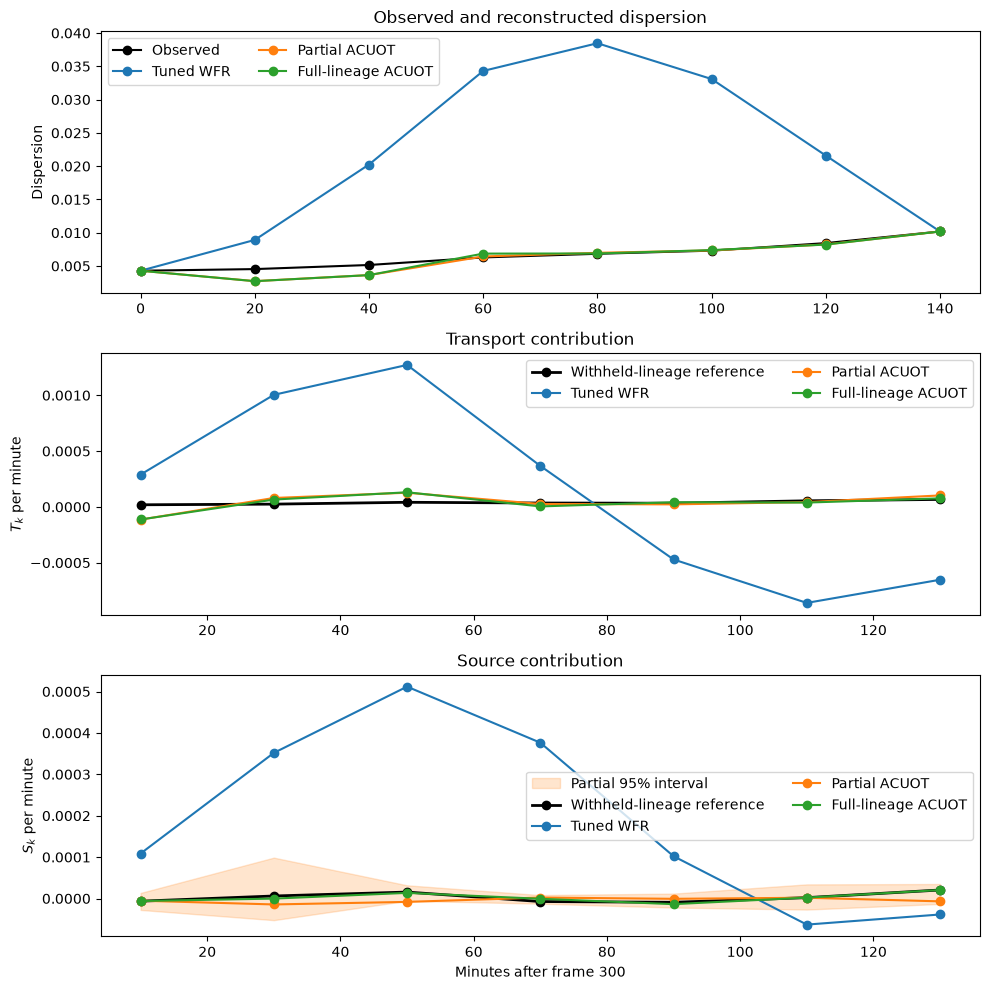

In [ ]:
def anchored_decomposition(solution):
    momentum_y = np.asarray(solution.V.D[1])
    momentum_x = np.asarray(solution.V.D[2])
    source = np.asarray(solution.V.Z)
    transport = (
        (
            2.0
            * (Y[None, :, :] - mu_y_mid[:, None, None])
            / N_mid[:, None, None]
            * momentum_y
            + 2.0
            * (X[None, :, :] - mu_x_mid[:, None, None])
            / N_mid[:, None, None]
            * momentum_x
        ).sum(axis=(1, 2))
        * CELL_AREA
    )
    source_contribution = (
        (source_kernel * source).sum(axis=(1, 2)) * CELL_AREA
    )
    return transport, source_contribution


def density_dispersion_at_nodes(solution):
    mass, first_y, first_x, raw_second = raw_moments(solution.U.D[0])
    return raw_second / mass - (first_y / mass) ** 2 - (first_x / mass) ** 2


def constraint_values(solution, blocks):
    centered_fields = solution.V.D + [solution.V.Z]
    values = []
    for block in blocks:
        value = sum(
            (kernel * field).sum(axis=(1, 2))
            for kernel, field in zip(block, centered_fields)
        ) * CELL_AREA
        values.append(np.asarray(value))
    return values


def normalized_block_violations(solution, lower, upper):
    values = constraint_values(solution, H)
    block_violations = []
    for value, lo, hi in zip(values, lower, upper):
        violation = np.maximum(np.maximum(lo - value, value - hi), 0.0)
        scale = np.maximum(1.0, np.maximum(np.abs(lo), np.abs(hi)))
        block_violations.append(float(np.max(violation / scale)))
    return block_violations


def endpoint_l2(solution):
    errors = [
        np.sqrt(((solution.U.D[0][0] - observed_density[0]) ** 2).sum() * CELL_AREA),
        np.sqrt(((solution.U.D[0][-1] - observed_density[-1]) ** 2).sum() * CELL_AREA),
    ]
    return float(max(errors))


def normalized_node_moment_error(solution):
    predicted = raw_moments(solution.U.D[0])
    observed = (N_node, P_y_node, P_x_node, R_node)
    errors = [
        np.max(np.abs(value - target) / np.maximum(1.0, np.abs(target)))
        for value, target in zip(predicted, observed)
    ]
    return float(max(errors))


def rmse(values):
    values = np.asarray(values)
    return float(np.sqrt(np.mean(values**2)))


def mae(values):
    return float(np.mean(np.abs(values)))


method_data = {
    "Tuned WFR": (wfr_solution, wfr_history, None, None),
    "Partial ACUOT": (
        partial_solution,
        partial_history,
        GL_partial,
        GU_partial,
    ),
    "Full-lineage ACUOT": (
        full_solution,
        full_history,
        GL_full,
        GU_full,
    ),
}

dO_dt = np.diff(O_node) / DT
T_reference = dO_dt - source_full
decompositions = {}
summary_rows = []

for name, (solution, history, lower, upper) in method_data.items():
    transport, source = anchored_decomposition(solution)
    decompositions[name] = (transport, source)
    l2_loss, relative_l2 = trajectory_l2(solution)
    block_violations = (
        None
        if lower is None
        else normalized_block_violations(solution, lower, upper)
    )
    summary_rows.append(
        {
            "method": name,
            "density_L2": l2_loss,
            "relative_density_L2": relative_l2,
            "T_MAE": mae(transport - T_reference),
            "T_RMSE": rmse(transport - T_reference),
            "S_MAE": mae(source - source_full),
            "S_RMSE": rmse(source - source_full),
            "closure_RMSE": rmse(transport + source - dO_dt),
            "final_CE_L2": float(np.sqrt(max(solution.dist_from_CE(), 0))),
            "iter_CE_L2": float(np.sqrt(max(history[1][-1], 0))),
            "iter_interp_L2": float(np.sqrt(max(history[2][-1], 0))),
            "endpoint_L2_max": endpoint_l2(solution),
            "node_moment_error": normalized_node_moment_error(solution),
            "moment_violation": (
                np.nan if block_violations is None else max(block_violations[:4])
            ),
            "source_violation": (
                np.nan if block_violations is None else block_violations[4]
            ),
            "minimum_density": float(np.min(solution.U.D[0])),
        }
    )

print_table(summary_rows)

interval_coverage = float(
    np.mean((source_full >= source_lower) & (source_full <= source_upper))
)
print(f"Partial-lineage interval coverage of the withheld source: {interval_coverage:.1%}")
print(
    "Full-lineage source-observable max error: "
    f"{np.max(np.abs(decompositions['Full-lineage ACUOT'][1] - source_full)):.3e}"
)

node_time = (node_frames - FRAME_START) * FRAME_DT_MINUTES
mid_time = 0.5 * (node_time[:-1] + node_time[1:])

fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=False)

axes[0].plot(node_time, O_node, "k-o", label="Observed")
for name, (solution, _, _, _) in method_data.items():
    axes[0].plot(node_time, density_dispersion_at_nodes(solution), "o-", label=name)
axes[0].set_ylabel("Dispersion")
axes[0].set_title("Observed and reconstructed dispersion")
axes[0].legend(ncol=2)

axes[1].plot(mid_time, T_reference, "k-o", linewidth=2, label="Withheld-lineage reference")
for name, (transport, _) in decompositions.items():
    axes[1].plot(mid_time, transport, "o-", label=name)
axes[1].set_ylabel(r"$T_k$ per minute")
axes[1].set_title("Transport contribution")
axes[1].legend(ncol=2)

axes[2].fill_between(
    mid_time,
    source_lower,
    source_upper,
    color="tab:orange",
    alpha=0.2,
    label="Partial 95% interval",
)
axes[2].plot(mid_time, source_full, "k-o", linewidth=2, label="Withheld-lineage reference")
for name, (_, source) in decompositions.items():
    axes[2].plot(mid_time, source, "o-", label=name)
axes[2].set_xlabel(f"Minutes after frame {FRAME_START}")
axes[2].set_ylabel(r"$S_k$ per minute")
axes[2].set_title("Source contribution")
axes[2].legend(ncol=2)

fig.tight_layout()
plt.show()

## Reading the result and limitations

The tuned WFR curve is the unconstrained baseline. Partial-lineage ACUOT answers the stated inference question; its source curve should satisfy the sampled interval while its moment constraints reproduce the observed count, centroid, and dispersion. Full-lineage ACUOT is an oracle showing what the same scalar-constrained formulation can recover when all division locations are revealed.

The summary separates density fidelity, decomposition error, numerical closure, endpoint error, continuity/interpolation diagnostics, and final constraint violation. A small direct closure residual is expected from midpoint time discretization; large moment or source violations instead indicate inadequate PPXA convergence.

This notebook deliberately implements one sequence, one validated window, one reveal fraction and seed, one short $\delta$ grid, and exactly the three requested method paths. It does not add all-sequence orchestration, repeated sampling trials, temporal smoothing, bootstrapping, continuous hyperparameter optimization, downloads, caches, or file exports.